In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

# Datensatz laden (als DataFrame)
wine = load_wine(as_frame=True)

# Typen der Komponenten prüfen
print(f"Typ von wine: {type(wine)}")
print(f"Typ von wine.data: {type(wine.data)}")
print(f"Typ von wine.target: {type(wine.target)}")

# Erste Einblicke
print("\nErste 5 Zeilen von wine.data:")
print(wine.data.head())

print("\nErste 5 Werte von wine.target:")
print(wine.target.head())

print(f"\nFeature names: {wine.feature_names}")
print(f"Target names: {wine.target_names}")
print(f"Data shape: {wine.data.shape}")

Typ von wine: <class 'sklearn.utils._bunch.Bunch'>
Typ von wine.data: <class 'pandas.DataFrame'>
Typ von wine.target: <class 'pandas.Series'>

Erste 5 Zeilen von wine.data:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             

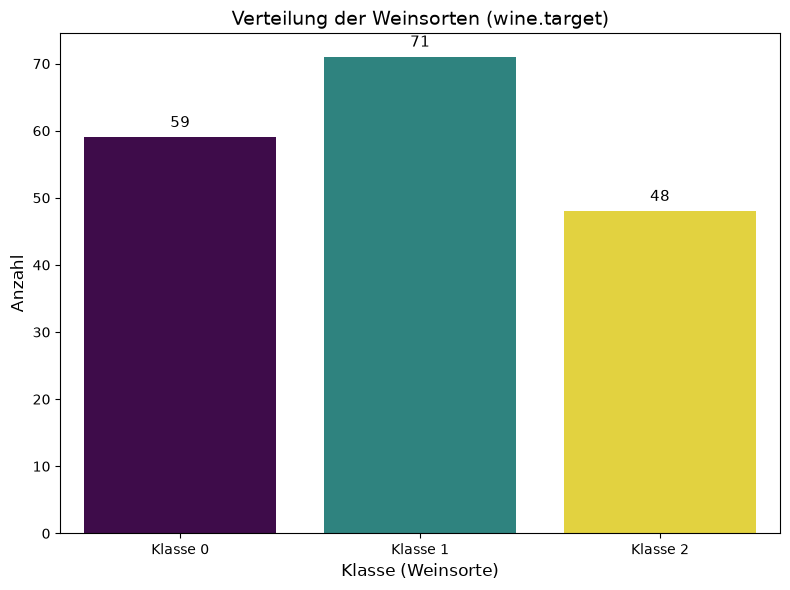

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Größe anpassen
plt.figure(figsize=(8, 6))

# Countplot erstellen (mit hue und legend=False)
sns.countplot(
    x=wine.target,
    hue=wine.target,
    palette='viridis',
    legend=False
)

# Titel und Achsenbeschriftungen
plt.title('Verteilung der Weinsorten (wine.target)', fontsize=14)
plt.xlabel('Klasse (Weinsorte)', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)

# X-Achsen-Labels anpassen
plt.xticks([0, 1, 2], ['Klasse 0', 'Klasse 1', 'Klasse 2'])

# Werte über den Balken anzeigen
for i, count in enumerate(wine.target.value_counts().sort_index()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=11)

# Layout optimieren
plt.tight_layout()
plt.show()

In [6]:
# Summenstatistik des Datensatzes
print("Summenstatistik von wine.data:")
print(wine.data.describe())

# Standardabweichungen berechnen
std_devs = wine.data.std()

# Variable mit der größten Standardabweichung
max_std_var = std_devs.idxmax()
max_std_value = std_devs.max()

print(f"\nDie Variable mit der größten Standardabweichung ist: {max_std_var} ({max_std_value:.2f})")

# Optional: Alle Standardabweichungen anzeigen
print("\nStandardabweichungen aller Variablen (absteigend sortiert):")
print(std_devs.sort_values(ascending=False))

Summenstatistik von wine.data:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453     

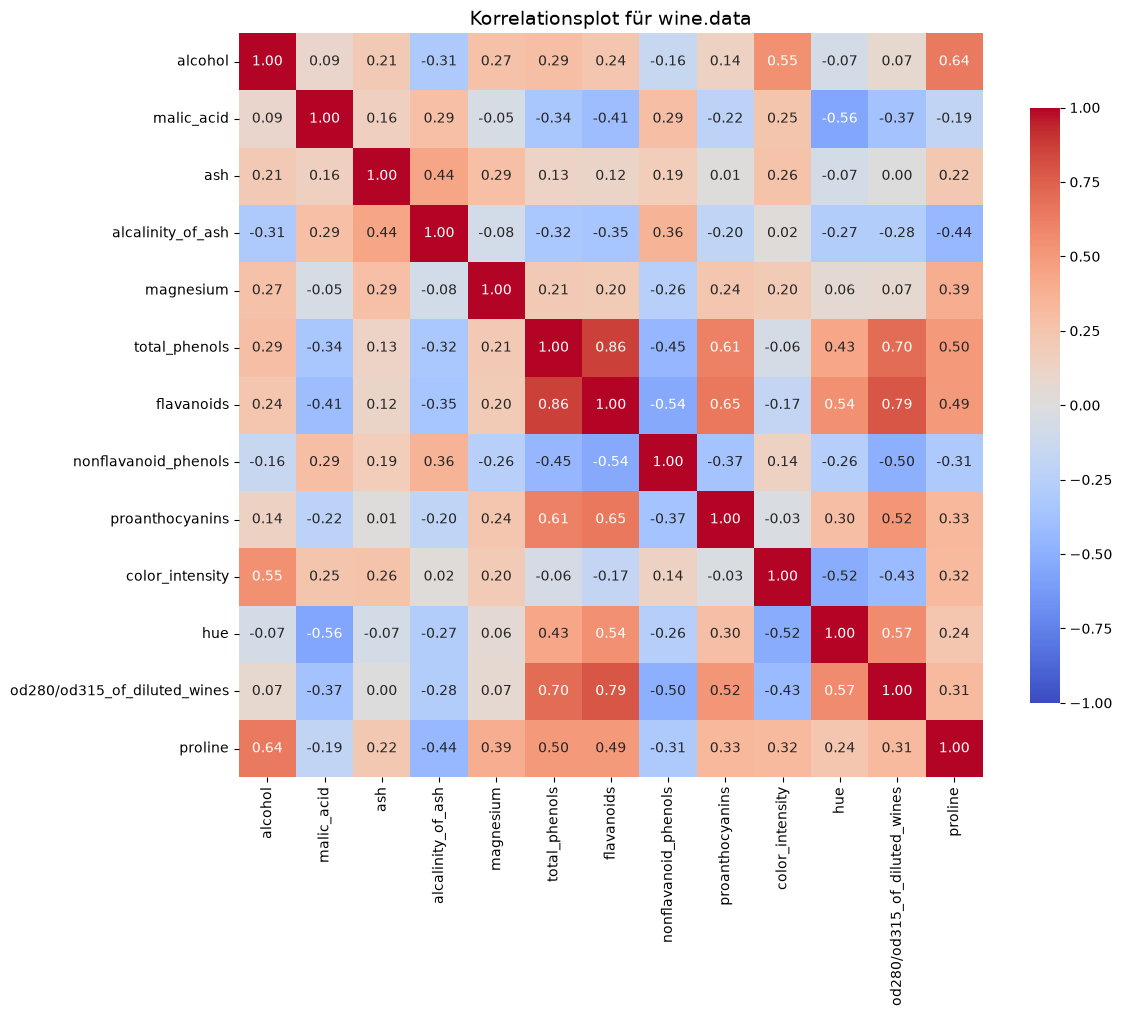

Stärkste positive Korrelationen:
total_phenols    flavanoids                      0.864564
flavanoids       od280/od315_of_diluted_wines    0.787194
total_phenols    od280/od315_of_diluted_wines    0.699949
flavanoids       proanthocyanins                 0.652692
alcohol          proline                         0.643720
total_phenols    proanthocyanins                 0.612413
hue              od280/od315_of_diluted_wines    0.565468
alcohol          color_intensity                 0.546364
flavanoids       hue                             0.543479
proanthocyanins  od280/od315_of_diluted_wines    0.519067
dtype: float64

Stärkste negative Korrelationen:
malic_acid            hue                            -0.561296
flavanoids            nonflavanoid_phenols           -0.537900
color_intensity       hue                            -0.521813
nonflavanoid_phenols  od280/od315_of_diluted_wines   -0.503270
total_phenols         nonflavanoid_phenols           -0.449935
alcalinity_of_ash     p

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Korrelationsmatrix berechnen
corr_matrix = wine.data.corr()

# Korrelationsplot erstellen
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Werte in den Zellen anzeigen
    cmap='coolwarm',      # Farbpalette: blau-weiß-rot
    vmin=-1, vmax=1,      # Wertebereich -1 bis 1
    square=True,          # Quadratische Zellen
    fmt='.2f',            # 2 Nachkommastellen
    cbar_kws={'shrink': 0.8}
)

plt.title('Korrelationsplot für wine.data', fontsize=14)
plt.tight_layout()
plt.show()

# Stärkste Korrelationen identifizieren
# Obere Dreiecksmatrix extrahieren (ohne Diagonale)
corr_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()

# Stärkste positive Korrelationen
print("Stärkste positive Korrelationen:")
print(corr_upper.sort_values(ascending=False).head(10))

# Stärkste negative Korrelationen
print("\nStärkste negative Korrelationen:")
print(corr_upper.sort_values(ascending=True).head(10))

Plot gespeichert als: ../output/Aufgabe3e.png
Vollständiger Pfad: C:\Users\tomak\Downloads\B-BIDA01XX\output\Aufgabe3e.png


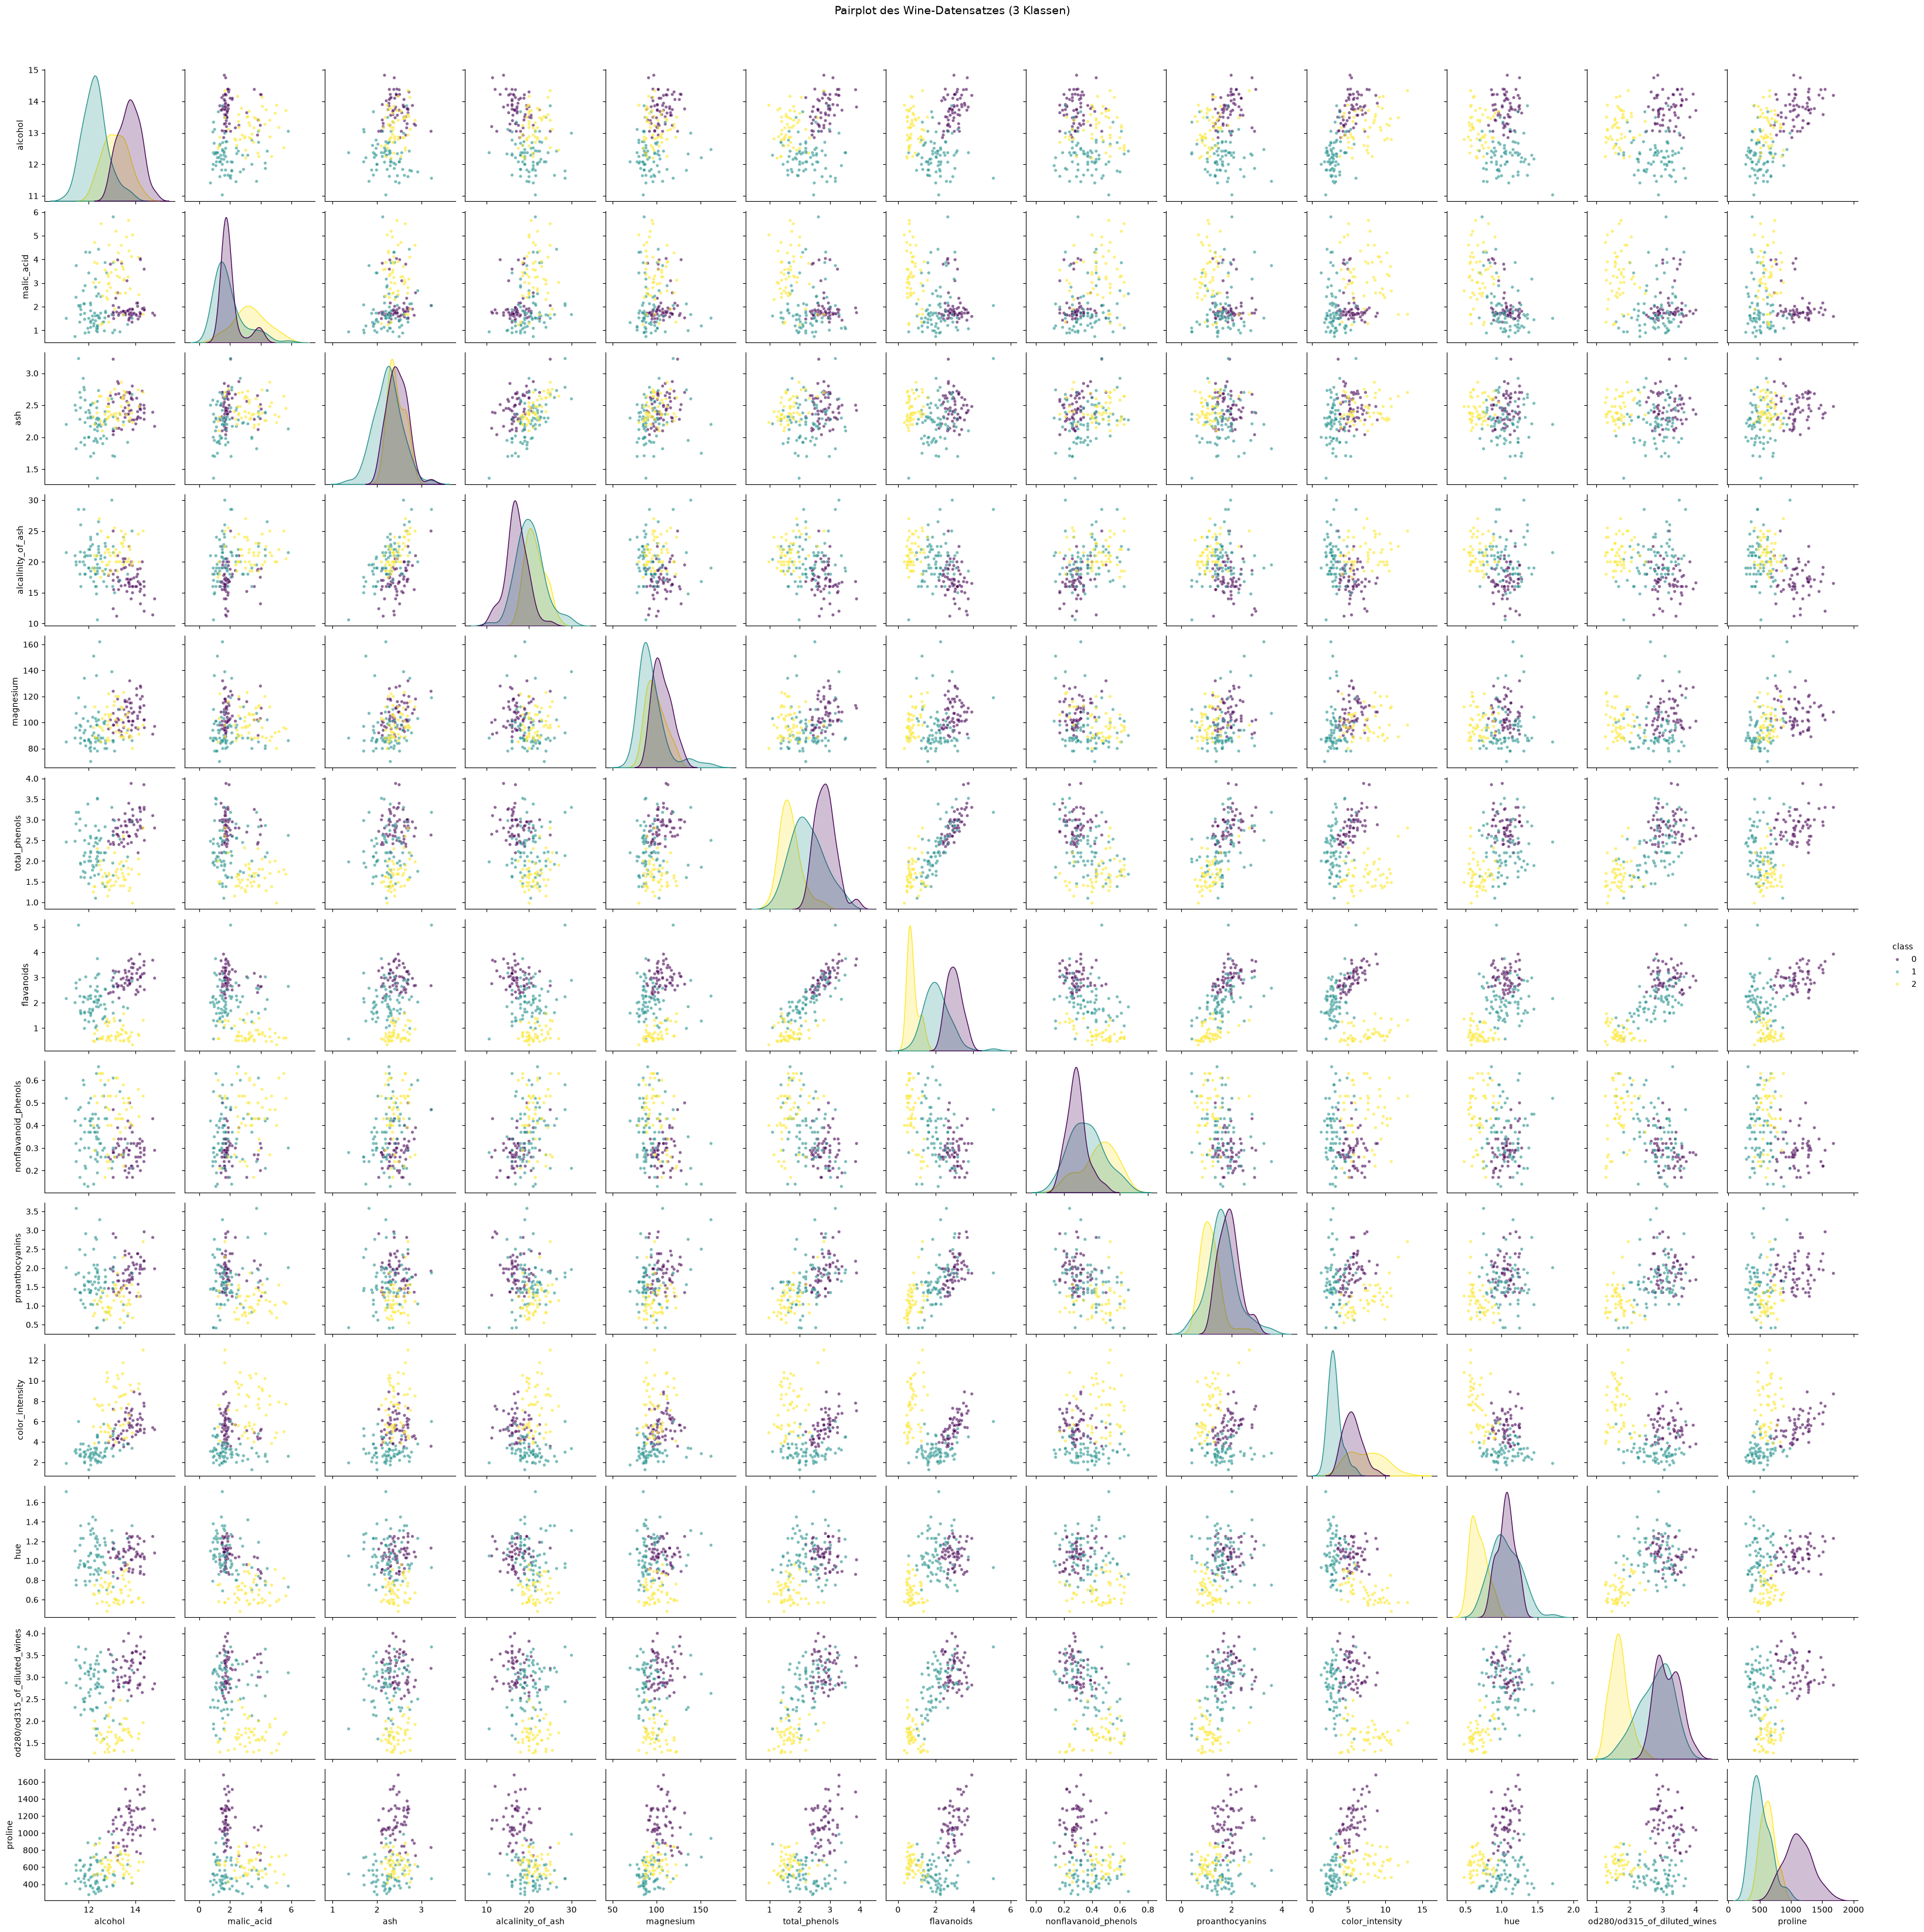

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# output-Ordner im Projekt-Hauptordner erstellen (eine Ebene höher)
os.makedirs('../output', exist_ok=True)

# wine.data und wine.target kombinieren
wine_df = pd.concat([wine.data, wine.target], axis=1)
wine_df.rename(columns={'target': 'class'}, inplace=True)

# Pairplot erstellen
pairplot = sns.pairplot(
    wine_df,
    hue='class',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 15}
)

# Titel setzen
pairplot.fig.suptitle('Pairplot des Wine-Datensatzes (3 Klassen)', y=1.02, fontsize=14)

# Speichern im output-Ordner des Projekt-Hauptordners
pairplot.fig.savefig('../output/Aufgabe3e.png', dpi=300, bbox_inches='tight')
print("Plot gespeichert als: ../output/Aufgabe3e.png")
print("Vollständiger Pfad: C:\\Users\\tomak\\Downloads\\B-BIDA01XX\\output\\Aufgabe3e.png")

# Plot anzeigen
plt.show()

C:\Users\tomak\miniforge3\envs\B-BIDA01XX\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tomak\miniforge3\envs\B-BIDA01XX\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tomak\miniforge3\envs\B-BIDA01XX\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Wi

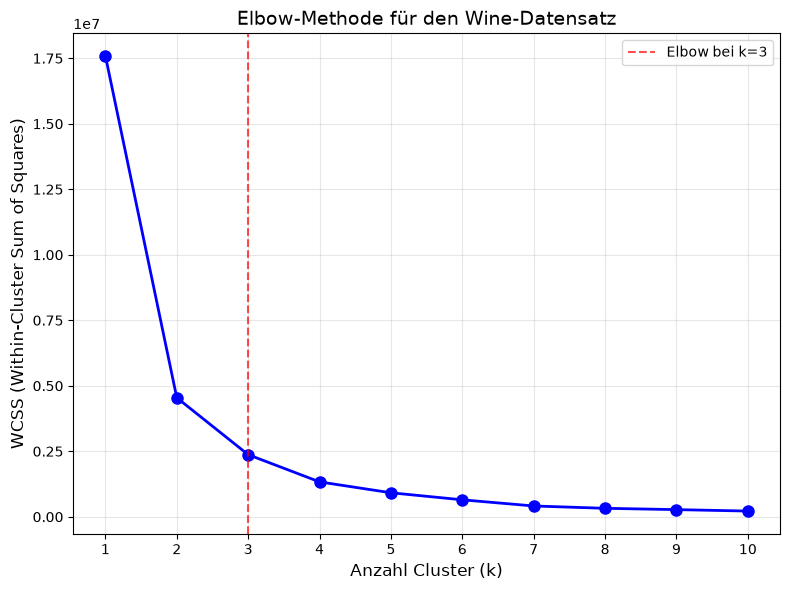

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# WCSS-Werte für verschiedene k berechnen
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(wine.data)
    wcss.append(kmeans.inertia_)

# Elbow-Plot erstellen
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, 'o-', color='blue', linewidth=2, markersize=8)
plt.xlabel('Anzahl Cluster (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow-Methode für den Wine-Datensatz', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Knick bei k=3 markieren
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow bei k=3')
plt.legend()

plt.tight_layout()
plt.show()

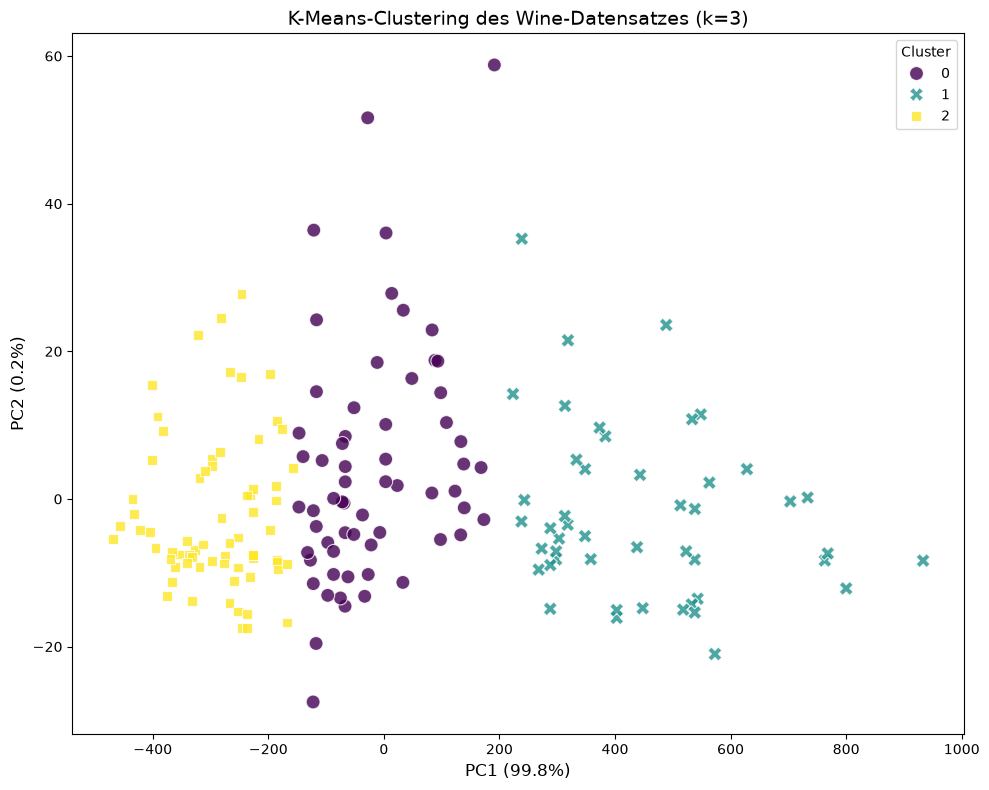

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# K-Means mit k=3 durchführen
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
wine_df['cluster'] = kmeans.fit_predict(wine.data)

# PCA für Visualisierung (2 Hauptkomponenten)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(wine.data)

# DataFrame mit PCA-Ergebnissen
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = wine_df['cluster']
pca_df['true_class'] = wine_df['class']

# PCA-Plot erstellen
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='viridis',
    style='cluster',
    s=100,
    alpha=0.8
)

plt.title('K-Means-Clustering des Wine-Datensatzes (k=3)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

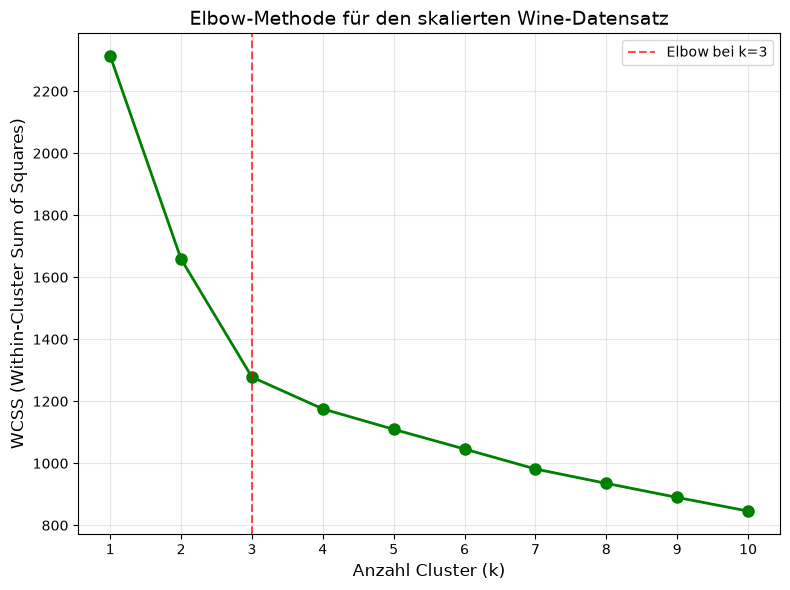

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Daten skalieren
scaler = StandardScaler()
scaled_data = scaler.fit_transform(wine.data)

# Skalierte Daten in DataFrame umwandeln
scaled_df = pd.DataFrame(scaled_data, columns=wine.feature_names)

# WCSS-Werte für verschiedene k berechnen
wcss_scaled = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss_scaled.append(kmeans.inertia_)

# Elbow-Plot für skalierte Daten erstellen
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss_scaled, 'o-', color='green', linewidth=2, markersize=8)
plt.xlabel('Anzahl Cluster (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow-Methode für den skalierten Wine-Datensatz', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Knick bei k=3 markieren
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow bei k=3')
plt.legend()

plt.tight_layout()
plt.show()